# Factorial state-space models for World Cup skill rating

**Deep dive.** This notebook builds a *factorial state-space model* (fSSM) for
international football and uses it to (1) rank national teams, (2) reconstruct how
their skill has evolved over time, and (3) predict outcomes of the 2026 FIFA World
Cup — all through the `dynestyx` factorial interface.

An fSSM partitions the latent state into `F` conditionally independent **factors**
(here, the teams), each with its own Markov dynamics, where every observation (a
match) is *local*: it depends only on the two teams involved.

$$
p(x_t \mid x_{t-1}) = \prod_{f=1}^{F} p\big(x_t^f \mid x_{t-1}^f\big),
\qquad
p(y_k \mid x_k) = p\big(y_k \mid x_k^{\text{home}(k)}, x_k^{\text{away}(k)}\big).
$$

This is the skill-rating model of **Duffield, Power & Rimella (2024)**, *"A
state-space perspective on modelling and inference for online skill rating"*
(JRSS-C). Each team's skill follows a random walk observed at irregular times, and
match outcomes follow a sigmoidal (Bradley–Terry-with-draws) likelihood. The key
modelling subtlety is that the home and away teams generally have **different time
gaps** since they last played — each factor propagates from *its own* last match
(Duffield et al. §3.4.3), which the factorial backend handles automatically.

We mirror the [cuthbert quickstart](https://state-space-models.github.io/cuthbert/quickstart/),
but expressed with `dynestyx`'s `FactorialDynamicalModel` + `dsx.sample` interface
rather than hand-rolled filtering.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    FactorialDynamicalModel,
    RandomWalkEvolution,
    MatchOutcomeObservation,
    Filter,
    Smoother,
    FactorialEKFConfig,
    FactorialEKFSmootherConfig,
    factorial_outcome_probabilities,
)

jax.config.update("jax_enable_x64", True)

## 1. Data: international results and the 2026 World Cup fixtures

We download Mart Jürisoo's open
[`international_results`](https://github.com/martj42/international_results) dataset
at runtime. Conveniently it already contains the **2026 World Cup fixtures** as
future rows with missing scores — exactly the matches we want to predict.

To keep the model focused and fast we restrict attention to the 48 teams in the
2026 World Cup and their head-to-head matches since 2015. Outcomes are encoded as
`0 = draw`, `1 = home win`, `2 = away win`.

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"])

# Future 2026 World Cup fixtures (scores not yet known).
future = df[
    df["home_score"].isna()
    & (df["tournament"] == "FIFA World Cup")
    & (df["date"] >= "2026-06-01")
].sort_values("date")
wc_teams = sorted(set(future["home_team"]) | set(future["away_team"]))
team_idx = {t: i for i, t in enumerate(wc_teams)}
F = len(wc_teams)

# Played matches among the 48 World Cup teams since 2015.
played = df.dropna(subset=["home_score", "away_score"]).copy()
played = played[
    (played["date"] >= "2015-01-01")
    & played["home_team"].isin(team_idx)
    & played["away_team"].isin(team_idx)
].sort_values("date").reset_index(drop=True)


def outcome(row):
    if row.home_score > row.away_score:
        return 1
    if row.home_score < row.away_score:
        return 2
    return 0


played["outcome"] = played.apply(outcome, axis=1)

# Time in years since the first match; add a tiny ramp so identical match dates
# become strictly increasing (dsx.sample requires strictly increasing times).
t0_date = played["date"].min()
K = len(played)
days = (played["date"] - t0_date).dt.days.to_numpy().astype(float)
obs_times = jnp.asarray(days / 365.25 + np.arange(K) * 1e-6)
obs_factor_indices = jnp.asarray(
    np.stack(
        [
            played["home_team"].map(team_idx).to_numpy(),
            played["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)
obs_values = jnp.asarray(played["outcome"].to_numpy().astype(np.int32))

print(f"{F} teams, {K} historical matches, {len(future)} World Cup fixtures to predict")

48 teams, 1314 historical matches, 72 World Cup fixtures to predict


## 2. The factorial model

We assemble a `FactorialDynamicalModel` from three reusable pieces:

- a per-factor **initial condition** $p(x_0^f) = \mathcal N(0, \sigma_0^2)$ (a vector
  distribution of event dimension $d=1$ — a scalar skill);
- a per-factor **random-walk evolution** $x_{t'}^f \mid x_t^f \sim
  \mathcal N\big(x_t^f, \tau^2 (t'-t)\big)$ (`RandomWalkEvolution`); and
- a **local match-outcome observation** acting on the two involved skills
  (`MatchOutcomeObservation`), a sigmoidal model with a draw margin $\varepsilon$ and
  a home advantage $h$ (Duffield et al. eq. 5).

The hyperparameters below are illustrative (skills measured in logit units, time in
years); §5 shows how to choose $\tau$ from the marginal likelihood.

In [3]:
INIT_SD = 0.6        # prior skill standard deviation
TAU = 0.45           # skill drift rate (per sqrt-year)
DRAW_MARGIN = 0.35   # draw propensity (epsilon)
HOME_ADVANTAGE = 0.1

D = 1  # scalar skill per team


def build_model(tau=TAU, init_sd=INIT_SD, draw_margin=DRAW_MARGIN, home_adv=HOME_ADVANTAGE):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(D), init_sd**2 * jnp.eye(D)),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=D),
        observation_model=MatchOutcomeObservation(
            draw_margin=draw_margin,
            home_advantage=home_adv,
            factor_state_dim=D,
        ),
        num_factors=F,
        num_local_factors=2,
        t0=0.0,
    )


def world_cup_model(tau=TAU, predict_times=None, predict_factor_indices=None):
    with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
        dsx.sample(
            "skill",
            build_model(tau=tau),
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
            predict_times=predict_times,
            predict_factor_indices=predict_factor_indices,
        )

## 3. Filtering: current team rankings

Running the model inside a `Filter` adds the marginal log-likelihood as a NumPyro
factor and records the **filtered** per-team skills $\mathbb E[x_t^f \mid y_{1:t}]$.
The last filtered skill of each team is its current rating.

In [4]:
trace = Predictive(world_cup_model, num_samples=1)(jax.random.PRNGKey(0))
final_skill = np.asarray(trace["skill_filtered_states_mean"][0, :, 0])  # (F,)
print(f"marginal log-likelihood: {float(trace['skill_marginal_loglik'][0]):.1f}")

order = np.argsort(final_skill)[::-1]
ranking = pd.DataFrame(
    {"team": [wc_teams[i] for i in order], "skill": final_skill[order]}
)
ranking.index = np.arange(1, F + 1)
ranking.head(15)

marginal log-likelihood: -1615.6


,team,skill
1,Portugal,0.686118
2,Brazil,0.667424
3,Argentina,0.620518
4,France,0.490118
5,Japan,0.414395
6,Spain,0.411311
7,Belgium,0.388429
8,Colombia,0.353956
9,South Korea,0.320544
10,Senegal,0.318067


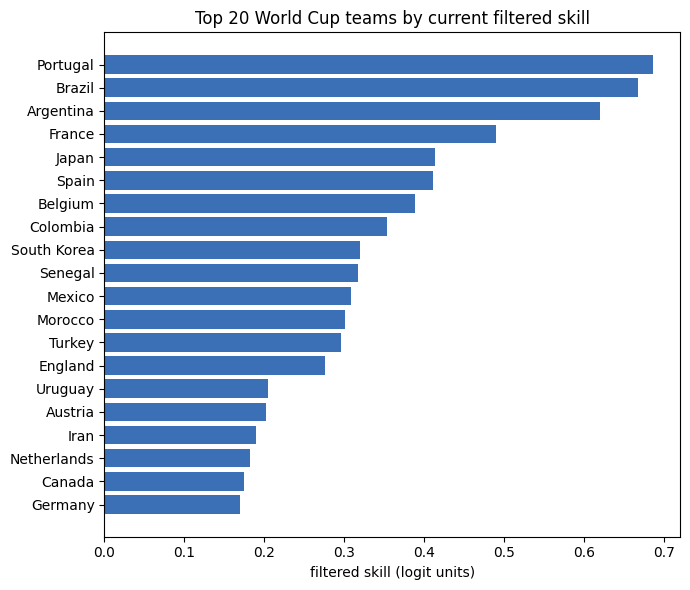

In [5]:
top = 20
fig, ax = plt.subplots(figsize=(7, 6))
top_order = order[:top][::-1]
ax.barh([wc_teams[i] for i in top_order], final_skill[top_order], color="#3b6fb6")
ax.set_xlabel("filtered skill (logit units)")
ax.set_title(f"Top {top} World Cup teams by current filtered skill")
fig.tight_layout()
plt.show()

## 4. Smoothing: historical skill trajectories

Filtering uses only past results; **smoothing** conditions each estimate on the
*entire* history, $p(x_t^f \mid y_{1:T})$. In a factorial model the smoothing
recursions decouple across factors, so each team's trajectory is smoothed
independently. `dynestyx` records the smoothed skill of each team at every match it
played, which we gather into per-team time series.

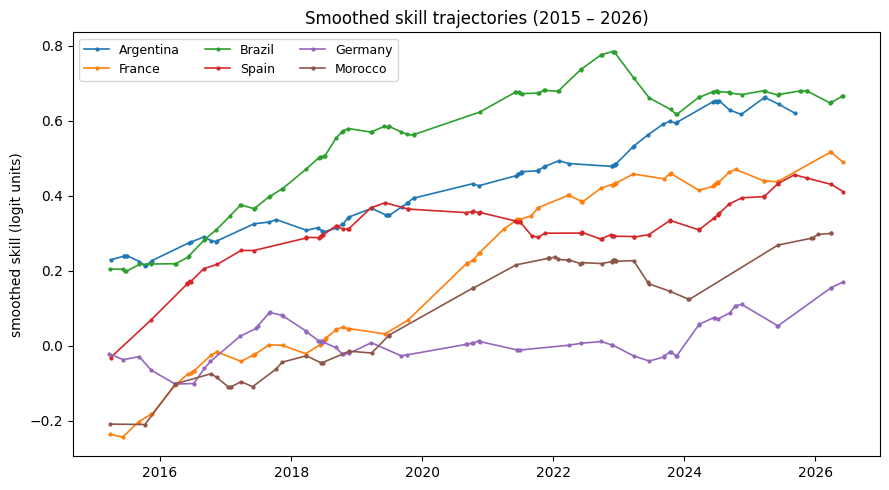

In [6]:
def smoothed_model():
    with Smoother(
        smoother_config=FactorialEKFSmootherConfig(record_smoothed_states_mean=True)
    ):
        dsx.sample(
            "skill",
            build_model(),
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
        )


strace = Predictive(smoothed_model, num_samples=1)(jax.random.PRNGKey(0))
smoothed_local = np.asarray(strace["skill_smoothed_local_states_mean"][0, :, :, 0])  # (K, 2)
idx_np = np.asarray(obs_factor_indices)
match_dates = played["date"].to_numpy()


def team_trajectory(team):
    i = team_idx[team]
    dates, skills = [], []
    for k in range(K):
        for j in range(2):
            if idx_np[k, j] == i:
                dates.append(match_dates[k])
                skills.append(smoothed_local[k, j])
    return np.array(dates), np.array(skills)


fig, ax = plt.subplots(figsize=(9, 5))
for team in ["Argentina", "France", "Brazil", "Spain", "Germany", "Morocco"]:
    if team in team_idx:
        d_, s_ = team_trajectory(team)
        ax.plot(d_, s_, marker=".", ms=4, lw=1.2, label=team)
ax.set_ylabel("smoothed skill (logit units)")
ax.set_title("Smoothed skill trajectories (2015 – 2026)")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

## 5. Choosing $\tau$ from the marginal likelihood

The `Filter` exposes $\log p(y_{1:K} \mid \theta)$, so we can compare drift rates
$\tau$ by their marginal likelihood — a model-selection workflow in the spirit of
Duffield et al. (Higher $\tau$ lets skills move faster; too high overfits recent
form, too low ignores genuine change.)

Two caveats. First, the factorial EKF marginal likelihood is a Gaussian/Laplace
approximation of the (categorical) evidence, so it is best read as a *relative*
criterion across settings rather than an absolute log-loss. Second, it is *not*
differentiable through the linearized categorical update, so we profile it over a
small grid here; for gradient-based inference (e.g. NUTS over $\tau$) use the
differentiable `FactorialPFConfig` (particle filter).

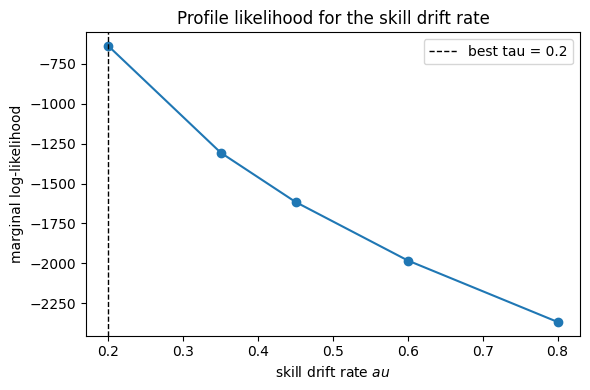

best tau: 0.2


In [7]:
from dynestyx.inference.integrations.cuthbert.factorial_filter import (
    compute_factorial_filter,
)

taus = np.array([0.2, 0.35, 0.45, 0.6, 0.8])
logliks = []
for tau in taus:
    ll, *_ = compute_factorial_filter(
        build_model(tau=float(tau)),
        FactorialEKFConfig(),
        None,
        obs_times=obs_times,
        obs_values=obs_values,
        obs_factor_indices=obs_factor_indices,
    )
    logliks.append(float(ll))
logliks = np.array(logliks)
best_tau = float(taus[int(np.argmax(logliks))])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus, logliks, "o-")
ax.axvline(best_tau, color="k", ls="--", lw=1, label=f"best tau = {best_tau}")
ax.set_xlabel(r"skill drift rate $	au$")
ax.set_ylabel("marginal log-likelihood")
ax.set_title("Profile likelihood for the skill drift rate")
ax.legend()
fig.tight_layout()
plt.show()
print("best tau:", best_tau)

## 6. Predicting the 2026 World Cup

To predict a future match we propagate the two involved teams' filtered skills to
the match date and integrate the observation model over the predictive skill
distribution. Passing `predict_times` and `predict_factor_indices` to `dsx.sample`
records the propagated joint-local skill distributions under the
`skill_predicted_*` sites; `factorial_outcome_probabilities` then Monte-Carlo
integrates the match-outcome model over them.

In [8]:
pred_dates = future["date"].to_numpy()
P = len(future)
predict_times = jnp.asarray(
    (future["date"] - t0_date).dt.days.to_numpy().astype(float) / 365.25
    + np.arange(P) * 1e-6
)
predict_factor_indices = jnp.asarray(
    np.stack(
        [
            future["home_team"].map(team_idx).to_numpy(),
            future["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)


def predict_model():
    world_cup_model(
        tau=TAU,
        predict_times=predict_times,
        predict_factor_indices=predict_factor_indices,
    )


ptrace = Predictive(predict_model, num_samples=1)(jax.random.PRNGKey(0))
pred_means = ptrace["skill_predicted_states"][0]          # (P, 2, 1)
pred_chols = ptrace["skill_predicted_states_chol_cov"][0]  # (P, 2, 1, 1)

probs = factorial_outcome_probabilities(
    MatchOutcomeObservation(
        draw_margin=DRAW_MARGIN, home_advantage=HOME_ADVANTAGE, factor_state_dim=D
    ),
    pred_means,
    pred_chols,
    key=jax.random.PRNGKey(1),
    n_samples=4000,
)
probs = np.asarray(probs)  # (P, 3): [draw, home win, away win]

predictions = pd.DataFrame(
    {
        "date": pd.to_datetime(pred_dates).strftime("%Y-%m-%d"),
        "home": future["home_team"].to_numpy(),
        "away": future["away_team"].to_numpy(),
        "P(home win)": probs[:, 1],
        "P(draw)": probs[:, 0],
        "P(away win)": probs[:, 2],
    }
)
predictions.round(3).head(16)

,date,home,away,P(home win),P(draw),P(away win)
0,2026-06-11,Mexico,South Africa,0.563,0.156,0.281
1,2026-06-11,South Korea,Czech Republic,0.625,0.140,0.235
2,2026-06-12,Canada,Bosnia and Herzegovina,0.586,0.152,0.262
3,2026-06-12,United States,Paraguay,0.477,0.167,0.356
4,2026-06-13,Qatar,Switzerland,0.339,0.163,0.497
5,2026-06-13,Brazil,Morocco,0.529,0.162,0.309
6,2026-06-13,Haiti,Scotland,0.374,0.168,0.458
7,2026-06-13,Australia,Turkey,0.398,0.166,0.436
8,2026-06-14,Sweden,Tunisia,0.374,0.169,0.457
9,2026-06-14,Netherlands,Japan,0.383,0.168,0.449


## 7. Discussion

We built a factorial state-space model of international football with `dynestyx`,
filtered it to rank the 2026 World Cup teams, smoothed it to recover historical
skill trajectories, and rolled it forward to predict tournament outcomes — reusing
the exact same `FactorialDynamicalModel` + `dsx.sample` model code across all three
inference tasks.

A few notes and natural extensions:

- **Per-factor time gaps.** Each team diffuses from *its own* last match, which the
  factorial backend tracks automatically (Duffield et al. §3.4.3) — this is what the
  factorial interface buys over a naive full-state filter.
- **Inference cost** is $O(N + K)$ in the number of teams and matches via the
  match-sparse factorial representation, versus $O(N\cdot K)$ for the dense joint.
- **Parameter inference.** The EKF marginal likelihood is convenient for profiling
  but not differentiable through the linearized categorical update; for gradient-based
  inference (e.g. NUTS over $\tau, \varepsilon, h$) use `FactorialPFConfig`.
- **Richer models.** Neutral-venue handling (no home advantage), bivariate
  attack/defence skills with a Poisson score likelihood (Dixon–Coles), and
  Ornstein–Uhlenbeck (mean-reverting) skill dynamics all fit the same factorial
  interface — more on this application is planned for a follow-up.